In [1]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df_final_reg = pd.read_csv('df_gym_pro_final.csv')
df_final_reg

,exercise_id,Exercise_Name,Sex,Age,BodyweightKg,eq_clean,level_idx,goal_clean,Base_Lift,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,predicted_weight,target_reps,weight_target,reps_target
0,1546,Low Cable Fly,F,33.0,58.30,Machine,3,Powerbuilding,Best3BenchKg,80.0,60.0,107.5,7.5,10,10.0,10
1,1440,Lat Pullover,F,43.0,73.10,Machine,0,Bodybuilding,Best3DeadliftKg,105.0,67.5,110.0,18.5,12,20.0,12
2,2733,Super ROM Overhead Cable Row,M,15.5,67.40,Machine,0,Athletics,Best3DeadliftKg,100.0,62.5,105.0,63.6,12,70.0,12
3,2731,Super ROM Lateral Dumbbell Raise,M,35.0,66.65,Dumbbell,0,Athletics,Best3DeadliftKg,137.5,122.5,170.0,16.0,12,10.0,12
4,1075,Half Kneeling Landmine Press,M,26.5,72.45,Barbell,1,Athletics,Best3BenchKg,90.0,50.0,125.0,22.4,12,30.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45234,2750,T-Bar Row (Chest Supported),M,22.5,81.20,Machine,2,Athletics,Best3DeadliftKg,130.0,115.0,185.0,112.1,12,130.0,12
45235,5,(BACK) Barbell Row,M,29.0,80.10,Barbell,2,Muscle & Sculpting,Best3DeadliftKg,217.5,135.0,257.5,108.3,15,142.5,14
45236,1170,High Step Up,M,36.5,81.40,Bodyweight,2,Athletics,Best3SquatKg,205.0,155.0,240.0,21.6,12,5.2,12
45237,1471,Lateral Raise (Machine),M,23.0,81.90,Machine,2,Bodybuilding,Best3DeadliftKg,195.0,145.0,250.0,50.3,10,60.0,10


/var/folders/8s/mgfxfqyn23qftsm7b6_dqkjh0000gn/T/ipykernel_41767/377344815.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final_reg, x='target_reps', palette='viridis')


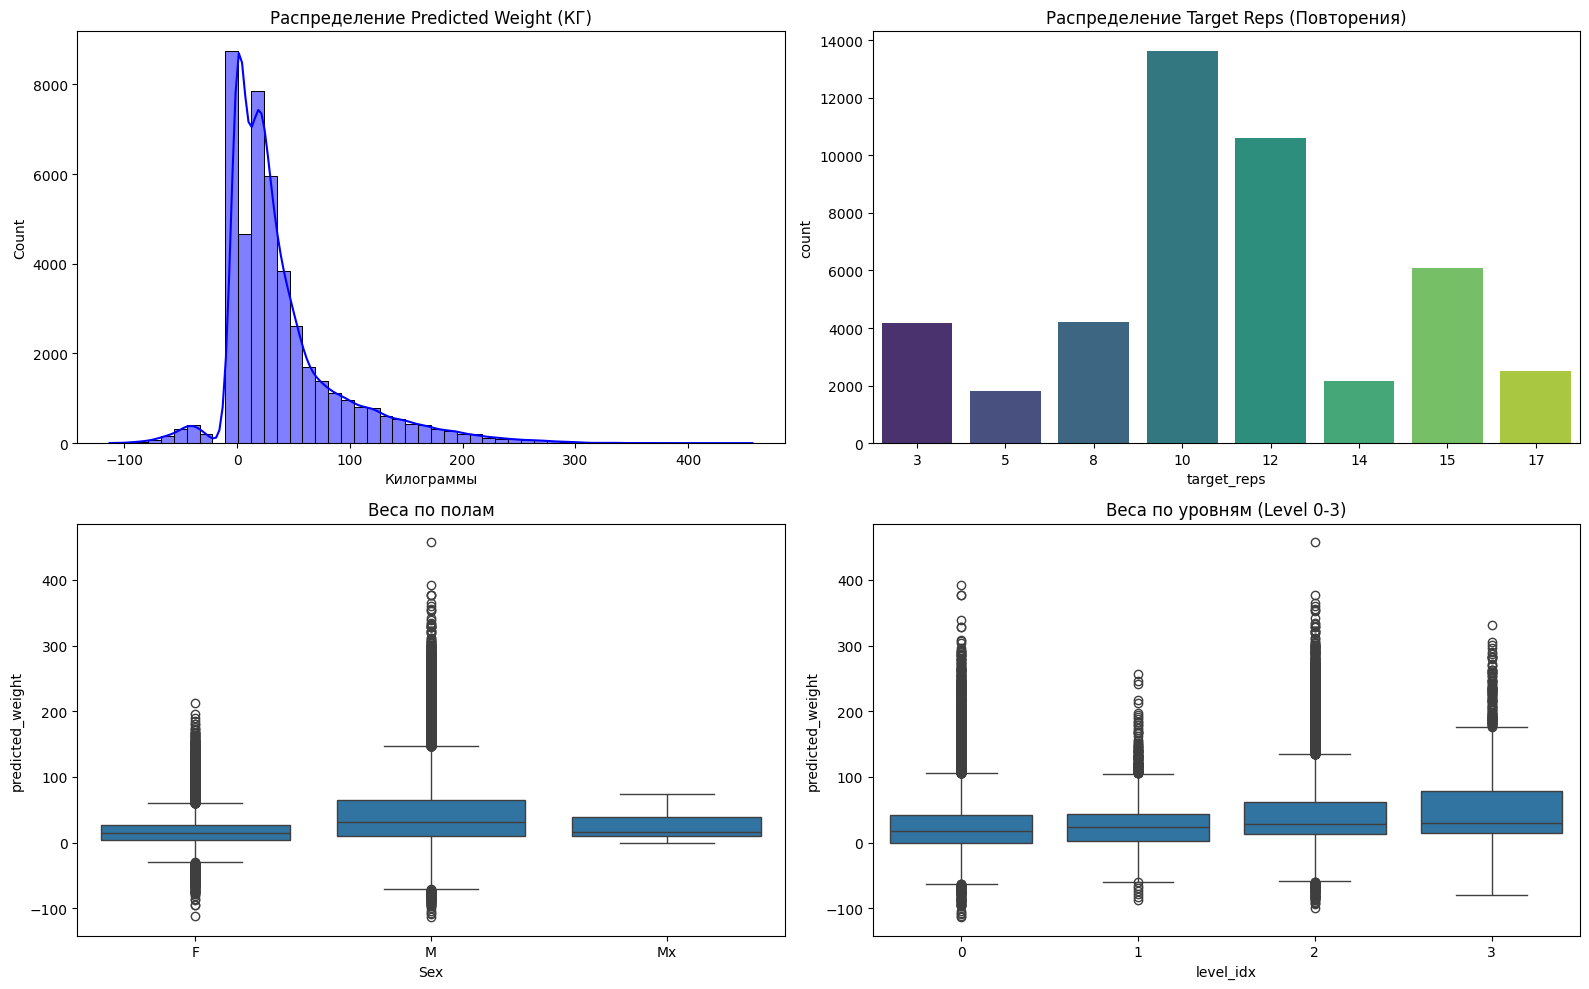

Статистическое описание весов:
count    45239.000000
mean        39.786436
std         52.348035
min       -113.000000
25%          5.000000
50%         24.000000
75%         53.100000
max        457.000000
Name: predicted_weight, dtype: float64


In [3]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_final_reg['predicted_weight'], bins=50, kde=True, color='blue')
plt.title('Распределение Predicted Weight (КГ)')
plt.xlabel('Килограммы')

plt.subplot(2, 2, 2)
sns.countplot(data=df_final_reg, x='target_reps', palette='viridis')
plt.title('Распределение Target Reps (Повторения)')

plt.subplot(2, 2, 3)
sns.boxplot(data=df_final_reg, x='Sex', y='predicted_weight')
plt.title('Веса по полам')

plt.subplot(2, 2, 4)
sns.boxplot(data=df_final_reg, x='level_idx', y='predicted_weight')
plt.title('Веса по уровням (Level 0-3)')

plt.tight_layout()
plt.show()

print("Статистическое описание весов:")
print(df_final_reg['predicted_weight'].describe())

In [4]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

features_light = [
    'Sex', 'Age', 'BodyweightKg', 'goal_clean', 
    'level_idx', 'eq_clean', 'exercise_id'
]

X_light = df_final_reg[features_light]
Y_light = df_final_reg[['predicted_weight', 'target_reps']]

cat_features_light = ['Sex', 'goal_clean', 'eq_clean', 'exercise_id']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_light, Y_light, test_size=0.2, random_state=42
)

model_light = CatBoostRegressor(
    loss_function='MultiRMSE',
    iterations=1000,
    learning_rate=0.04,
    depth=10,
    verbose=100
)

model_light.fit(X_train_l, y_train_l, cat_features=cat_features_light, eval_set=(X_test_l, y_test_l))

0:	learn: 51.0582998	test: 50.3838744	best: 50.3838744 (0)	total: 73ms	remaining: 1m 12s
100:	learn: 20.9776961	test: 17.6918586	best: 17.6918586 (100)	total: 1.92s	remaining: 17.1s
200:	learn: 19.7655592	test: 16.9752454	best: 16.9752454 (200)	total: 3.98s	remaining: 15.8s
300:	learn: 19.0439478	test: 16.8248583	best: 16.8248583 (300)	total: 6.09s	remaining: 14.1s
400:	learn: 18.3901357	test: 16.7417183	best: 16.7417183 (400)	total: 8.3s	remaining: 12.4s
500:	learn: 17.7568614	test: 16.6917956	best: 16.6857761 (476)	total: 10.7s	remaining: 10.7s
600:	learn: 17.1817750	test: 16.6596735	best: 16.6583141 (598)	total: 14.2s	remaining: 9.41s
700:	learn: 16.6375954	test: 16.6557560	best: 16.6480679 (642)	total: 17.9s	remaining: 7.62s
800:	learn: 16.1830856	test: 16.6524026	best: 16.6480679 (642)	total: 21.6s	remaining: 5.37s
900:	learn: 15.7649696	test: 16.6531472	best: 16.6480679 (642)	total: 25.6s	remaining: 2.81s
999:	learn: 15.3703726	test: 16.6445336	best: 16.6409119 (994)	total: 29.4s

CatBoostRegressor(depth=10, iterations=1000, learning_rate=0.04, loss_function='MultiRMSE', verbose=100)

In [5]:
model_light.save_model("weight_predictor_light.cbm")
print("✅ Light-модель весов сохранена в weight_predictor_light.cbm")

✅ Light-модель весов сохранена в weight_predictor_light.cbm
